In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


In [2]:
data = pd.read_csv('healthcare_dataset1.csv')
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
# data preprocessing and visualization 
data.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [4]:
data.duplicated().sum()

np.int64(534)

In [5]:
data.drop_duplicates(inplace=True)

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.describe()

,Age,Billing Amount,Room Number
count,54966.000000,54966.000000,54966.000000
mean,51.535185,25544.306284,301.124404
std,19.605661,14208.409711,115.223143
min,13.000000,-2008.492140,101.000000
25%,35.000000,13243.718641,202.000000
50%,52.000000,25542.749145,302.000000
75%,68.000000,37819.858159,401.000000
max,89.000000,52764.276736,500.000000


<Axes: ylabel='Billing Amount'>

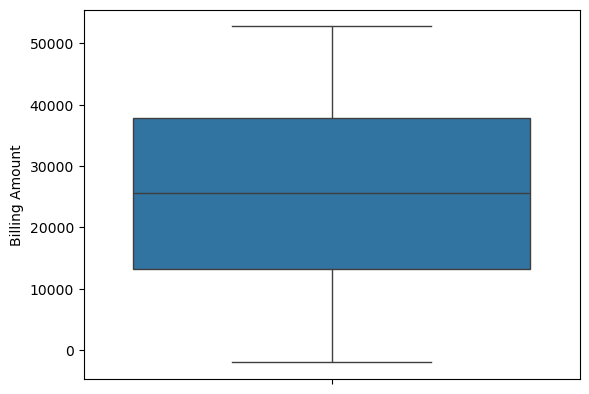

In [8]:
import seaborn as sns
sns.boxplot(data['Billing Amount'])

<Axes: ylabel='Age'>

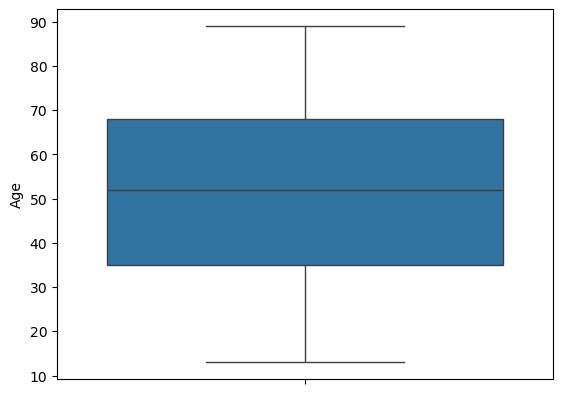

In [9]:
sns.boxplot(data['Age'])

In [10]:
data= data.drop(columns= ['Name', "Discharge Date", 'Insurance Provider', 'Billing Amount', 'Room Number'])
data.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Admission Type,Medication,Test Results
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Urgent,Paracetamol,Normal
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Emergency,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Emergency,Aspirin,Normal
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Elective,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Urgent,Penicillin,Abnormal


In [11]:
X= data.drop(columns=["Test Results"])
y= data["Test Results"]
X.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Admission Type,Medication
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Urgent,Paracetamol
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Emergency,Ibuprofen
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Emergency,Aspirin
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Elective,Ibuprofen
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Urgent,Penicillin


In [12]:
y.head()

0          Normal
1    Inconclusive
2          Normal
3        Abnormal
4        Abnormal
Name: Test Results, dtype: object

In [13]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)
print("X_train shape: {}".format(X_train.shape)) 
print("X_test shape: {}".format(X_test.shape))

print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))

X_train shape: (43972, 9)
X_test shape: (10994, 9)
y_train shape: (43972,)
y_test shape: (10994,)


In [14]:
categorical_columns = [
    "Gender", "Blood Type", "Medical Condition",
    "Date of Admission", "Doctor", "Hospital", "Admission Type", "Medication"]

numerical_columns = ["Age"]
# Transformer
categorical_Transformer = OneHotEncoder(handle_unknown='ignore')
numerical_Transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_Transformer, numerical_columns),
    ("cat", categorical_Transformer, categorical_columns)
])


In [15]:
# Pipeline for DecisionTreeClassifier
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
            ('classifier', DecisionTreeClassifier())])

In [16]:
# Fit and predict
dt_model= dt_pipeline.fit(X_train, y_train)
dt_predictions = dt_pipeline.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))

Decision Tree Accuracy: 0.3789339639803529


In [ ]:
# Access the DecisionTreeClassifier from the pipeline
dt_classifier = dt_pipeline.named_steps['classifier']

# Get feature importances
feature_importances = dt_classifier.feature_importances_

# Print feature importances
#print("Feature Importances:")
for i, importance in enumerate(feature_importances):
    print(f"Feature {i}:{importance}")


# If you have feature names, you can print them with their importances:
# (Assuming your preprocessor includes a step to get feature names)
feature_names = dt_pipeline.named_steps['preprocessor'].get_feature_names_out()
for i, importance in enumerate(feature_importances):
    print(f"{feature_names[i]}: {importance}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting feature importances with different colors

plt.figure(figsize=(10, 6))

# Generate a list of colors (you can customize these)
colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_feature_importances)))

plt.barh(list(sorted_feature_importances.keys()), 
         list(sorted_feature_importances.values()), 
         color=colors)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model with the appropriate 'average' setting
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro') # or 'micro' or 'weighted'
recall = recall_score(y_test, y_pred, average='macro') # or 'micro' or 'weighted'
f1 = f1_score(y_test, y_pred, average='macro') # or 'micro' or 'weighted'

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")